# Day 1 — NLP Fundamentals & Word Embeddings


In [6]:
%pip install spacy nltk gensim scikit-learn pandas matplotlib joblib
!python -m spacy download en_core_web_sm

  Using cached spacy-3.8.16-cp312-cp312-win_amd64.whl.metadata (28 kB)
  Using cached nltk-3.10.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached gensim-4.4.0-cp312-cp312-win_amd64.whl.metadata (8.6 kB)
  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pandas-3.0.6-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached murmurhash-1.0.15-cp312-cp312-win_amd64.whl.metadata (2.3 kB)
  Using cached cymem-2.0.13-cp312-cp312-win_amd64.whl.metadata (9.9 kB)
  Using cached preshed-3.0.13-cp312-cp312-win_amd64.whl.metadata (5.4 kB)
  Using cached thinc-8.3.13-cp312-cp312-win_amd64.whl.metadata (15 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress t

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     -- ------------------------------------- 0.8/12.8 MB 2.2 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.8 MB 2.2 MB/s eta 0:00:06
     -- ------------------------------------- 0.8/12.8 MB 2.2 MB/s eta 0:00:06
     ---- ----------------------------------- 1.3/12.8 MB 1.2 MB/s eta 0:00:10
     ---- ----------------------------------- 1.6/12.8 MB 1.3 MB/s eta 0:00:09
     ---- ----------------------------------- 1.6/12.8 MB 1.3 MB/s eta 0:00:09
     ----- ---------------------------------- 1.8/12.8 MB 1.1 MB/s eta 0:00:10
     ----- ---------------------------------- 1.8/12.8 MB 1.1 MB/s eta 0:00:10
     ------ --------------------------------- 2.1/12.8 MB 1.0 MB/s eta 0:00:11
     ------ --------------------------------- 2.1/12.8 MB 1.0 MB/s eta 0:


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import text_preprocessing as tp

df = pd.read_csv("Tweets.csv")[["airline_sentiment", "airline", "text"]]
print(df.shape)
df.airline_sentiment.value_counts(normalize=True).round(3)

(14640, 3)


airline_sentiment
negative    0.627
neutral     0.212
positive    0.161
Name: proportion, dtype: float64

## Task 1 

In [ ]:
samples = [
    "@united your flight wasn't good!!! delayed 3 hrs sooooo bad :( http://t.co/x #fail",
    "Thx @SouthwestAir 4 the free upgrade #bestairline",
    "can't believe they lost my bag... AGAIN. #neveragain",
]
for s in samples:
    print(s)
    for name, toks in tp.compare_tokenizers(s).items():
        print(f"  {name:11s} {toks}")
    print()

@united your flight wasn't good!!! delayed 3 hrs sooooo bad :( http://t.co/x #fail
  whitespace  ['@united', 'your', 'flight', "wasn't", 'good!!!', 'delayed', '3', 'hrs', 'sooooo', 'bad', ':(', 'http://t.co/x', '#fail']
  nltk_tweet  ['@united', 'your', 'flight', "wasn't", 'good', '!', '!', '!', 'delayed', '3', 'hrs', 'sooo', 'bad', ':(', 'http://t.co/x', '#fail']
  spacy       ['@united', 'your', 'flight', 'was', "n't", 'good', '!', '!', '!', 'delayed', '3', 'hrs', 'sooooo', 'bad', ':(', 'http://t.co/x', '#', 'fail']

Thx @SouthwestAir 4 the free upgrade #bestairline
  whitespace  ['Thx', '@SouthwestAir', '4', 'the', 'free', 'upgrade', '#bestairline']
  nltk_tweet  ['thx', '@southwestair', '4', 'the', 'free', 'upgrade', '#bestairline']
  spacy       ['Thx', '@SouthwestAir', '4', 'the', 'free', 'upgrade', '#', 'bestairline']

can't believe they lost my bag... AGAIN. #neveragain
  whitespace  ["can't", 'believe', 'they', 'lost', 'my', 'bag...', 'AGAIN.', '#neveragain']
  nltk_tweet  ["c

In [3]:
from nltk.stem import PorterStemmer
ps, nlp = PorterStemmer(), tp.get_nlp()
words = ["delayed", "delays", "cancelled", "flying", "flew", "better", "worst", "was", "luggage", "customers"]
pd.DataFrame({
    "word": words,
    "stem (NLTK Porter)": [ps.stem(w) for w in words],
    "lemma (spaCy)": [nlp(w)[0].lemma_ for w in words],
})

,word,stem (NLTK Porter),lemma (spaCy)
0,delayed,delay,delay
1,delays,delay,delay
2,cancelled,cancel,cancel
3,flying,fli,fly
4,flew,flew,fly
5,better,better,well
6,worst,worst,worst
7,was,wa,be
8,luggage,luggag,luggage
9,customers,custom,customer


In [4]:
for t in tp.pos_tag("The crew was not helpful and my flight got cancelled again!"):
    print(t)

('The', 'DET', 'DT')
('crew', 'NOUN', 'NN')
('was', 'AUX', 'VBD')
('not', 'PART', 'RB')
('helpful', 'ADJ', 'JJ')
('and', 'CCONJ', 'CC')
('my', 'PRON', 'PRP$')
('flight', 'NOUN', 'NN')
('got', 'VERB', 'VBD')
('cancelled', 'VERB', 'VBN')
('again', 'ADV', 'RB')
('!', 'PUNCT', '.')


In [5]:
# Do negative tweets use different parts of speech than positive ones?
prof = {}
for lab in ["negative", "neutral", "positive"]:
    c = tp.pos_profile(df[df.airline_sentiment == lab].text.sample(min(1500, (df.airline_sentiment == lab).sum()), random_state=0))
    tot = sum(c.values())
    prof[lab] = {k: v / tot for k, v in c.items()}
pd.DataFrame(prof).fillna(0).loc[["NOUN","VERB","ADJ","ADV","PROPN","INTJ","PRON","PUNCT"]].round(3)

,negative,neutral,positive
NOUN,0.177,0.171,0.174
VERB,0.119,0.105,0.099
ADJ,0.046,0.034,0.057
ADV,0.047,0.033,0.048
PROPN,0.089,0.145,0.134
INTJ,0.005,0.007,0.006
PRON,0.093,0.096,0.094
PUNCT,0.105,0.114,0.138


### 1d. Stopwords — the sentiment trap

In [6]:
from spacy.lang.en.stop_words import STOP_WORDS
neg = ["not", "no", "never", "nor", "n't", "cannot", "too", "very", "but", "against", "without"]
print("Default spaCy stopwords that carry sentiment:", [w for w in neg if w in STOP_WORDS])

ex = "The flight was not good, but the crew was never rude"
for m in ["minimal", "tokens", "lemma", "content"]:
    print(f"{m:8s} {tp.preprocess(ex, m)}")
print("\nNaive stopword removal:", " ".join(w for w in ex.lower().split() if w not in STOP_WORDS))

Default spaCy stopwords that carry sentiment: ['not', 'no', 'never', 'nor', "n't", 'cannot', 'too', 'very', 'but', 'against', 'without']
minimal  The flight was not good, but the crew was never rude
tokens   the flight was not good but the crew was never rude
lemma    the flight be not good but the crew be never rude
content  flight not good but crew never rude

Naive stopword removal: flight good, crew rude


In [7]:
row = df.text.iloc[3]
print("RAW    :", row)
for m in tp.MODES:
    print(f"{m:7s}:", tp.preprocess(row, m))

RAW    : @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
minimal: xxuser it's really aggressive to blast obnoxious "entertainment" in your guests' faces & they have little recourse
tokens : xxuser it 's really aggressive to blast obnoxious entertainment in your guests faces they have little recourse
lemma  : xxuser it be really aggressive to blast obnoxious entertainment in your guest face they have little recourse
content: xxuser really aggressive blast obnoxious entertainment guest face little recourse


## Task 2 

In [8]:
from gensim.models import Word2Vec

sentences = list(tp.tokenize_many(df.text, mode="tokens"))   # lowercase tokens, no lemmatization
print(len(sentences), "sentences; avg length", np.mean([len(s) for s in sentences]).round(1))

w2v = Word2Vec(
    sentences, vector_size=100, window=5, min_count=5,
    sg=1, negative=10, epochs=30, workers=4, seed=42,
)
print("vocab size:", len(w2v.wv))

14640 sentences; avg length 18.7
vocab size: 3108


In [16]:
def nn(word, topn=8):
    if word not in w2v.wv:
        return f"'{word}' not in vocab"
    return ", ".join(f"{w} ({s:.2f})" for w, s in w2v.wv.most_similar(word, topn=topn))

for w in ["delay", "luggage", "refund", "rude", "thanks", "cancelled", "worst", "gate", "hold"]:
    print(f"{w:10s} → {nn(w)}\n")

delay      → 719 (0.50), mechanical (0.50), delayed (0.50), fixing (0.48), delays (0.47), occurred (0.47), icing (0.47), flightation (0.46)

luggage    → bag (0.66), bags (0.65), belongings (0.63), aspen (0.61), baggage (0.54), carousel (0.53), suitcase (0.51), wallet (0.50)

refund     → penalty (0.55), receipt (0.53), refunds (0.53), accept (0.51), fee (0.49), courtesy (0.49), required (0.49), benefit (0.47)

rude       → unhelpful (0.63), karen (0.57), bothered (0.55), pleasant (0.54), courteous (0.53), yelled (0.53), unfriendly (0.53), unprofessional (0.53)

thanks     → thank (0.66), thx (0.59), thnx (0.55), 😀 (0.54), shoutout (0.53), prompt (0.53), impressive (0.50), ty (0.50)

cancelled  → flightled (0.73), flighted (0.69), 386 (0.57), rescheduled (0.56), girlfriend (0.54), flightation (0.54), cxl (0.53), reschedule (0.52)

worst      → ever (0.72), experienced (0.64), horrendous (0.60), best (0.57), biggest (0.55), horrible (0.52), costumer (0.52), horrid (0.52)

gate       → 4

**What to notice**
- Neighbors reflect *shared context*, not synonymy: `good` and `bad` are usually close (they appear in the same slots). Check it below.
- 14k tweets is tiny; rare words are noisy. Compare `min_count`, `window`, `epochs`.
- Domain wins: `hold`, `gate`, `bag` mean airline things here — a general-purpose model wouldn't know that.

In [10]:
for a, b in [("good", "bad"), ("delayed", "cancelled"), ("great", "awful"), ("great", "thanks")]:
    if a in w2v.wv and b in w2v.wv:
        print(f"sim({a}, {b}) = {w2v.wv.similarity(a, b):.2f}")

sim(good, bad) = 0.51
sim(delayed, cancelled) = 0.47
sim(great, awful) = 0.36
sim(great, thanks) = 0.34


In [11]:
# Sensitivity: window size changes what 'similar' means (small = syntactic, large = topical)
for win in (2, 10):
    m = Word2Vec(sentences, vector_size=100, window=win, min_count=5, sg=1, epochs=30, workers=4, seed=42)
    if "delay" in m.wv:
        print(f"window={win:2d}  delay → {[w for w,_ in m.wv.most_similar('delay', topn=8)]}")

window= 2  delay → ['occurred', 'layover', 'delayed', 'nearly', 'term', '45min', 'hit', 'flightation']
window=10  delay → ['incompetence', 'delayed', 'deplaned', 'fixing', 'operation', 'wait', 'maintenance', 'icing']


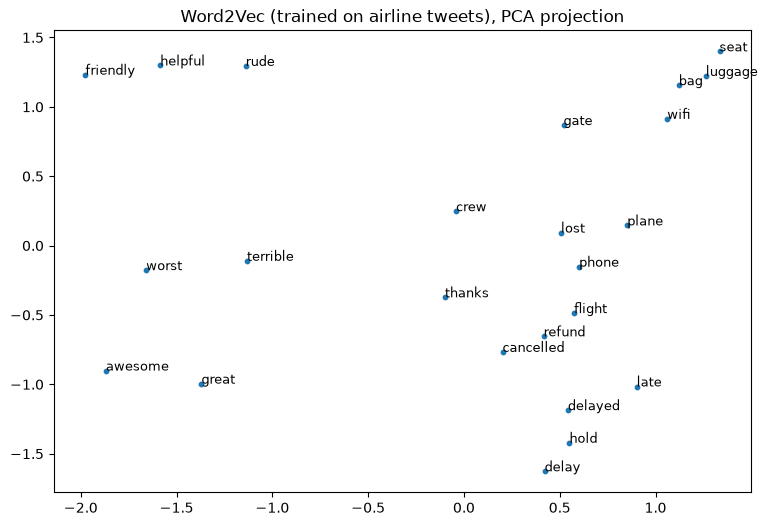

In [12]:
# 2-D map of selected words
from sklearn.decomposition import PCA
cands = ["delay","delayed","cancelled","late","luggage","bag","lost","refund","rude","helpful","friendly",
         "thanks","great","awesome","worst","terrible","gate","flight","plane","crew","seat","wifi","hold","phone"]
words = [w for w in cands if w in w2v.wv]
xy = PCA(2, random_state=0).fit_transform(np.array([w2v.wv[w] for w in words]))
plt.figure(figsize=(9, 6)); plt.scatter(xy[:,0], xy[:,1], s=10)
for (x, y), w in zip(xy, words): plt.annotate(w, (x, y), fontsize=9)
plt.title("Word2Vec (trained on airline tweets), PCA projection"); plt.show()

### Reflection

**1. Which neighbor lists made sense, and which didn't?**
Most of the useful ones were clear. `luggage` gave `bag`, `bags`, `baggage` and `suitcase`. `thanks` gave `thank`, `thx` and `ty`, so the model picked up slang on its own. `rude` gave `unhelpful` and `unprofessional`. The messy ones were `gate` and `cancelled`, which returned flight numbers like `4567` and odd tokens like `flightled`. The dataset is only about 14k tweets, so rare words don't get enough examples to be reliable.

**2. Did `good` and `bad` end up close?**
Yes, `sim(good, bad) = 0.51`. Opposite words appear in similar sentences ("the crew was ___"), so Word2Vec places them near each other. That means raw embeddings don't capture sentiment well, and they'd be a weak feature for a classifier on their own.

**3. What would I change for the TF-IDF model?**
I'd keep negations like "not" and "no" and skip stopword removal, because removing them can flip the meaning. I'd also add bigrams so phrases like "not good" count as one feature.